In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interaction_type_bout.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interaction_type_bout.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interaction_type_bout.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/interaction_type_bout.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/interaction_type_bout.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/interaction_type_bout.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

gh_order = ['GH Fed-Fed', 'GH Fed-Starved', 'GH Starved-Starved']
si_order = ['SI Fed-Fed', 'SI Fed-Starved', 'SI Starved-Starved']

palette_gh = {
    'GH Fed-Fed': '#4C72B0',
    'GH Fed-Starved': '#55A868',
    'GH Starved-Starved': '#C44E52',
}

palette_si = {
    'SI Fed-Fed': "#5A46A8",
    'SI Fed-Starved': '#55A868',
    'SI Starved-Starved': '#C44E52',
}

si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

si = si.sort_values(['Condition', 'file', 'start_frame'])
gh = gh.sort_values(['Condition', 'file', 'start_frame'])

si['interaction_number'] = (
    si.groupby(['Condition', 'file']).cumcount() + 1
)

gh['interaction_number'] = (
    gh.groupby(['Condition', 'file']).cumcount() + 1
)

df = pd.concat([gh, si], ignore_index=True)

initial_type_order = sorted(df['initial_type'].dropna().unique())


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/1532052914.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/1532052914.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


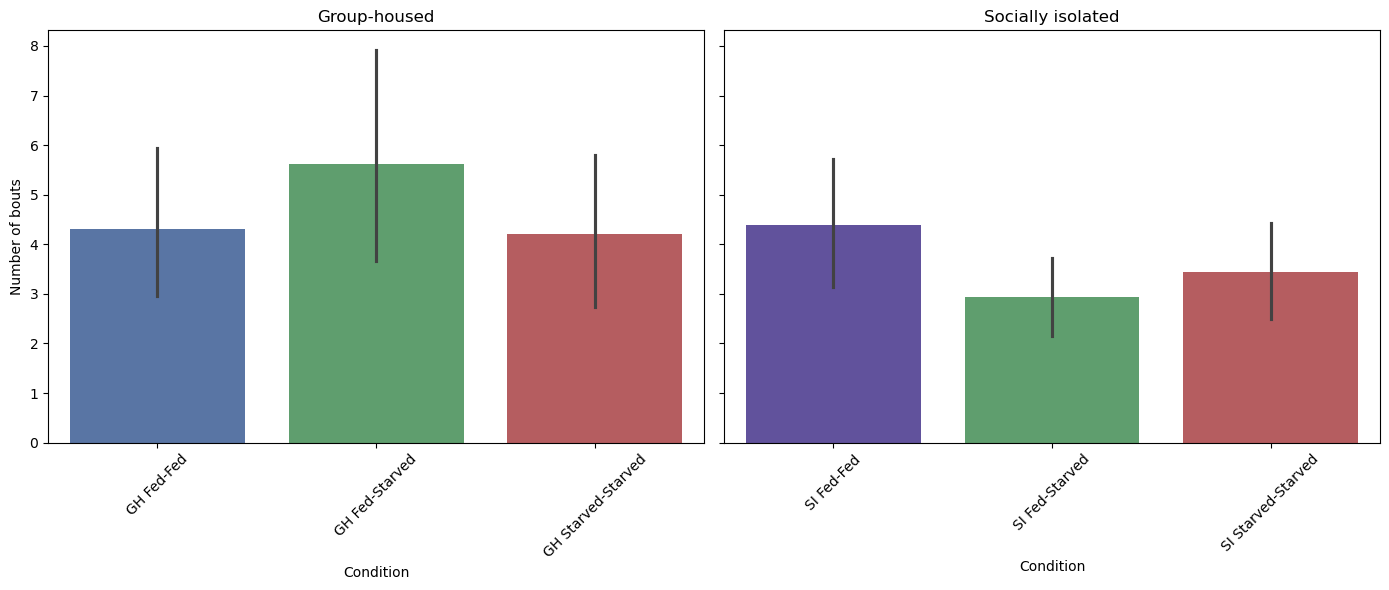

In [20]:
# Number of bouts per file
bout_counts = (
    df.groupby(['Condition', 'file'], as_index=False)
      .size()
      .rename(columns={'size': 'n_bouts'})
)

gh_counts = bout_counts[bout_counts['Condition'].str.contains('GH')].copy()
si_counts = bout_counts[bout_counts['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_counts,
    x='Condition',
    y='n_bouts',
    order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Number of bouts')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.barplot(
    data=si_counts,
    x='Condition',
    y='n_bouts',
    order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [21]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import pandas as pd

def simple_stats(counts, order, group_name, y_col):

    print(f"\n===== {group_name} =====")

    data = [
        counts[counts['Condition'] == c][y_col].dropna()
        for c in order
    ]

    H, p = kruskal(*data)
    print(f"Kruskal-Wallis: H = {H:.3f}, p = {p:.4f}")

    results = []

    for c1, c2 in combinations(order, 2):
        x = counts[counts['Condition'] == c1][y_col].dropna()
        y = counts[counts['Condition'] == c2][y_col].dropna()

        U, p = mannwhitneyu(x, y, alternative='two-sided')

        results.append({
            'group': group_name,
            'comparison': f'{c1} vs {c2}',
            'median_1': x.median(),
            'median_2': y.median(),
            'p_value': p
        })

    results = pd.DataFrame(results)
    results['p_fdr'] = multipletests(results['p_value'], method='fdr_bh')[1]

    display(results)

    return results


gh_stats = simple_stats(gh_counts, gh_order, 'GH', 'n_bouts')
si_stats = simple_stats(si_counts, si_order, 'SI', 'n_bouts')


===== GH =====
Kruskal-Wallis: H = 0.309, p = 0.8567


,group,comparison,median_1,median_2,p_value,p_fdr
0,GH,GH Fed-Fed vs GH Fed-Starved,3.0,3.5,0.617414,0.906184
1,GH,GH Fed-Fed vs GH Starved-Starved,3.0,3.0,0.906184,0.906184
2,GH,GH Fed-Starved vs GH Starved-Starved,3.5,3.0,0.704355,0.906184



===== SI =====
Kruskal-Wallis: H = 1.537, p = 0.4637


,group,comparison,median_1,median_2,p_value,p_fdr
0,SI,SI Fed-Fed vs SI Fed-Starved,4.0,3.0,0.245349,0.524868
1,SI,SI Fed-Fed vs SI Starved-Starved,4.0,3.5,0.524868,0.524868
2,SI,SI Fed-Starved vs SI Starved-Starved,3.0,3.5,0.511353,0.524868


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/3613729833.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/3613729833.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


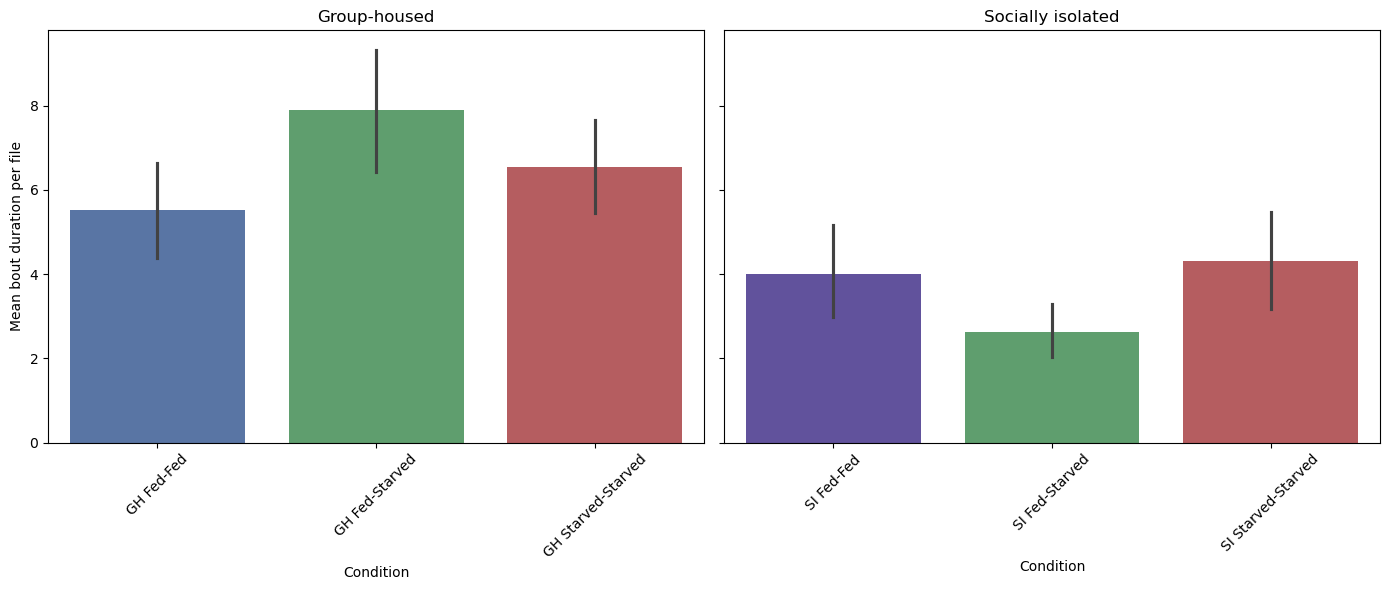

In [22]:
# Mean bout duration per file
duration_per_file = (
    df.groupby(['Condition', 'file'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

gh_duration = duration_per_file[duration_per_file['Condition'].str.contains('GH')].copy()
si_duration = duration_per_file[duration_per_file['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_duration,
    x='Condition',
    y='mean_bout_duration',
    order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Mean bout duration per file')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.barplot(
    data=si_duration,
    x='Condition',
    y='mean_bout_duration',
    order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [23]:
gh_duration_stats = simple_stats(gh_duration, gh_order, 'GH', 'mean_bout_duration')
si_duration_stats = simple_stats(si_duration, si_order, 'SI', 'mean_bout_duration')


===== GH =====
Kruskal-Wallis: H = 5.429, p = 0.0662


,group,comparison,median_1,median_2,p_value,p_fdr
0,GH,GH Fed-Fed vs GH Fed-Starved,4.843750,7.821429,0.022848,0.068543
1,GH,GH Fed-Fed vs GH Starved-Starved,4.843750,7.000000,0.293278,0.293278
2,GH,GH Fed-Starved vs GH Starved-Starved,7.821429,7.000000,0.272414,0.293278



===== SI =====
Kruskal-Wallis: H = 5.295, p = 0.0708


,group,comparison,median_1,median_2,p_value,p_fdr
0,SI,SI Fed-Fed vs SI Fed-Starved,3.600,2.625,0.081953,0.122930
1,SI,SI Fed-Fed vs SI Starved-Starved,3.600,4.100,0.489507,0.489507
2,SI,SI Fed-Starved vs SI Starved-Starved,2.625,4.100,0.031671,0.095012


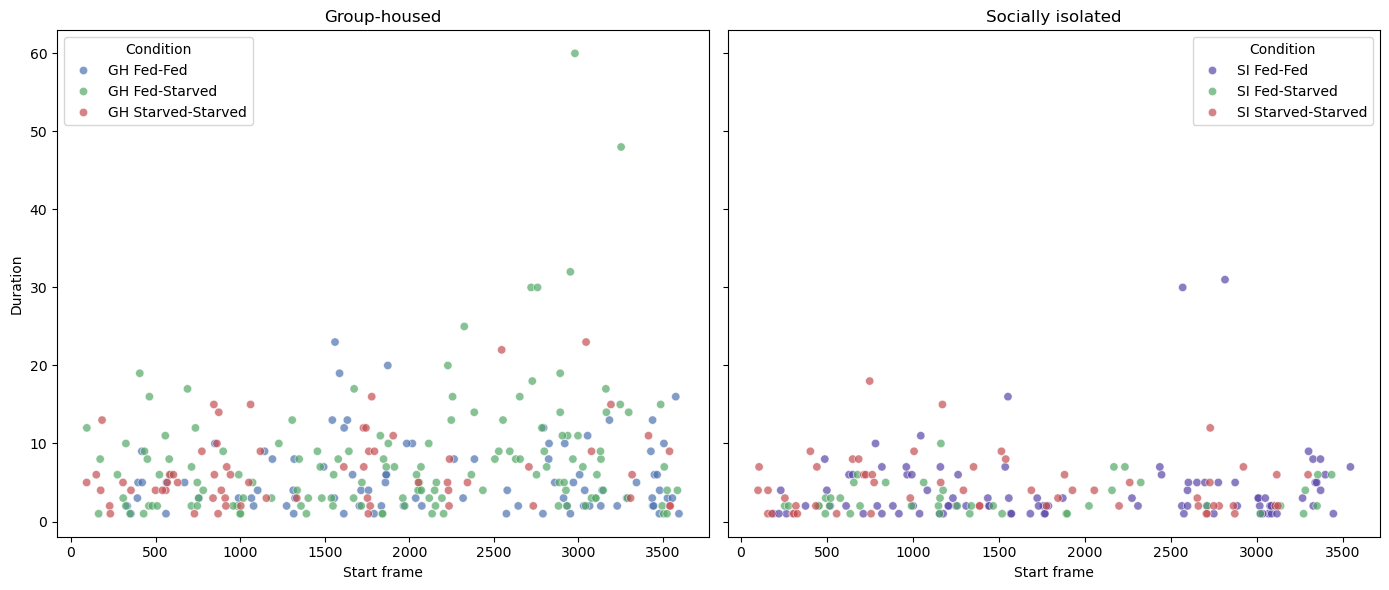

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.scatterplot(
    data=gh,
    x='start_frame',
    y='duration',
    hue='Condition',
    hue_order=gh_order,
    palette=palette_gh,
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Start frame')
axes[0].set_ylabel('Duration')

# ---------------- SI ----------------
sns.scatterplot(
    data=si,
    x='start_frame',
    y='duration',
    hue='Condition',
    hue_order=si_order,
    palette=palette_si,
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Start frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


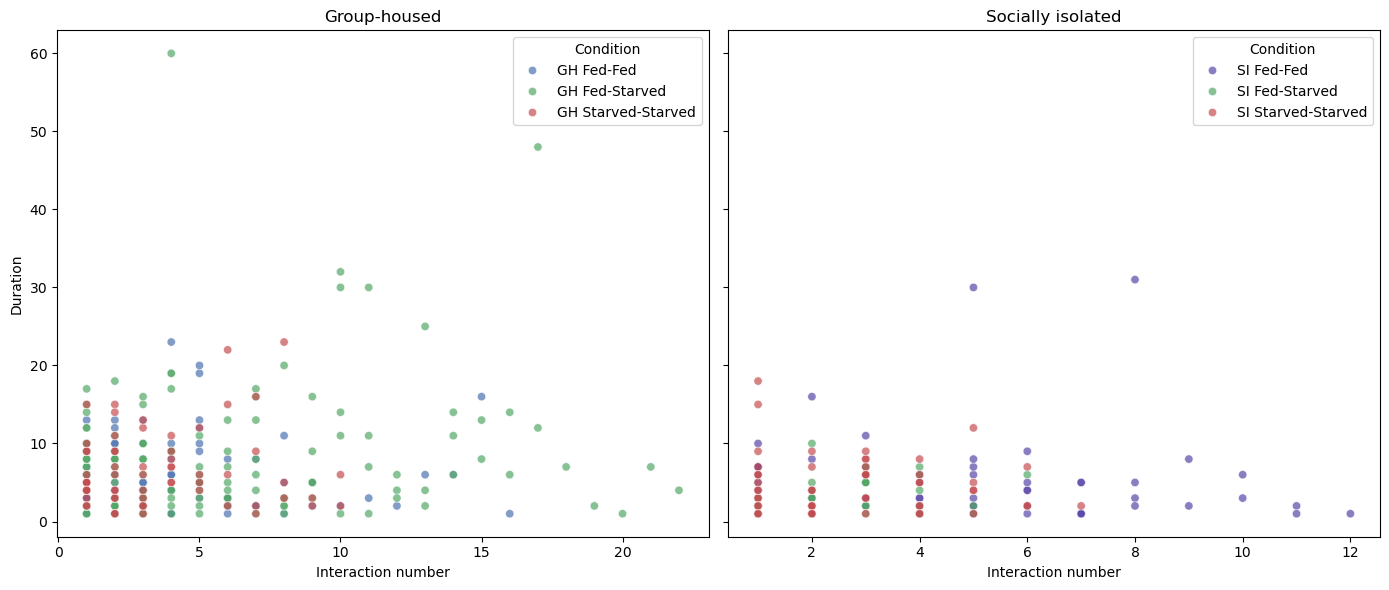

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.scatterplot(
    data=gh,
    x='interaction_number',
    y='duration',
    hue='Condition',
    hue_order=gh_order,
    palette=palette_gh,
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Interaction number')
axes[0].set_ylabel('Duration')

# ---------------- SI ----------------
sns.scatterplot(
    data=si,
    x='interaction_number',
    y='duration',
    hue='Condition',
    hue_order=si_order,
    palette=palette_si,
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Interaction number')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


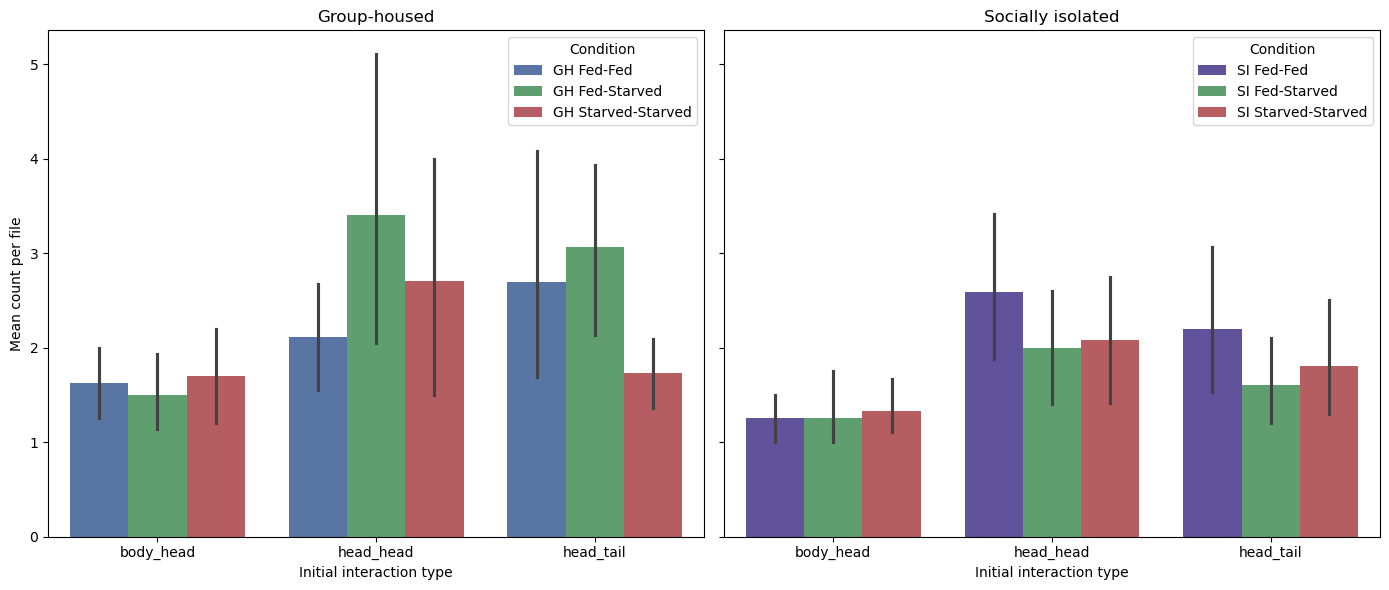

In [26]:
# Mean count per file for each initial interaction type
counts = (
    df.groupby(['Condition', 'file', 'initial_type'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

gh_counts = counts[counts['Condition'].str.contains('GH')].copy()
si_counts = counts[counts['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_counts,
    x='initial_type',
    y='count',
    hue='Condition',
    order=initial_type_order,
    hue_order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('Mean count per file')

# ---------------- SI ----------------
sns.barplot(
    data=si_counts,
    x='initial_type',
    y='count',
    hue='Condition',
    order=initial_type_order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


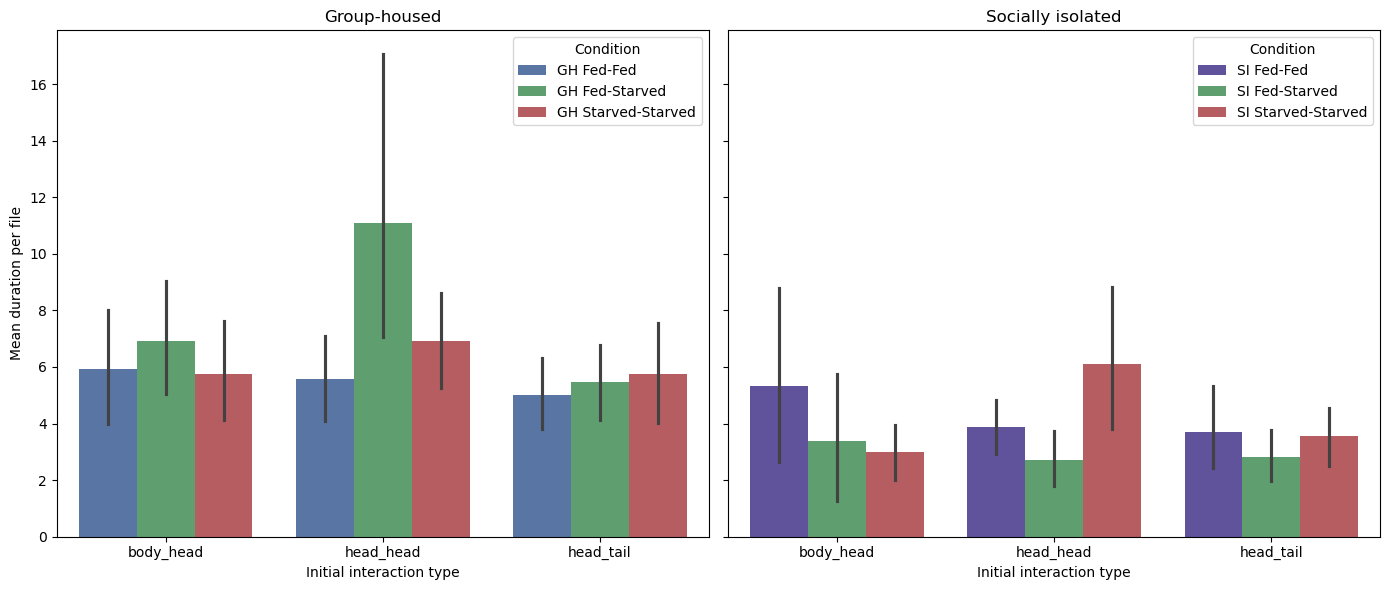

In [27]:
# Mean duration per file for each initial interaction type
duration_by_type = (
    df.groupby(['Condition', 'file', 'initial_type'], as_index=False)['duration']
      .mean()
)

gh_duration_by_type = duration_by_type[duration_by_type['Condition'].str.contains('GH')].copy()
si_duration_by_type = duration_by_type[duration_by_type['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_duration_by_type,
    x='initial_type',
    y='duration',
    hue='Condition',
    order=initial_type_order,
    hue_order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('Mean duration per file')

# ---------------- SI ----------------
sns.barplot(
    data=si_duration_by_type,
    x='initial_type',
    y='duration',
    hue='Condition',
    order=initial_type_order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/59042353.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/59042353.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


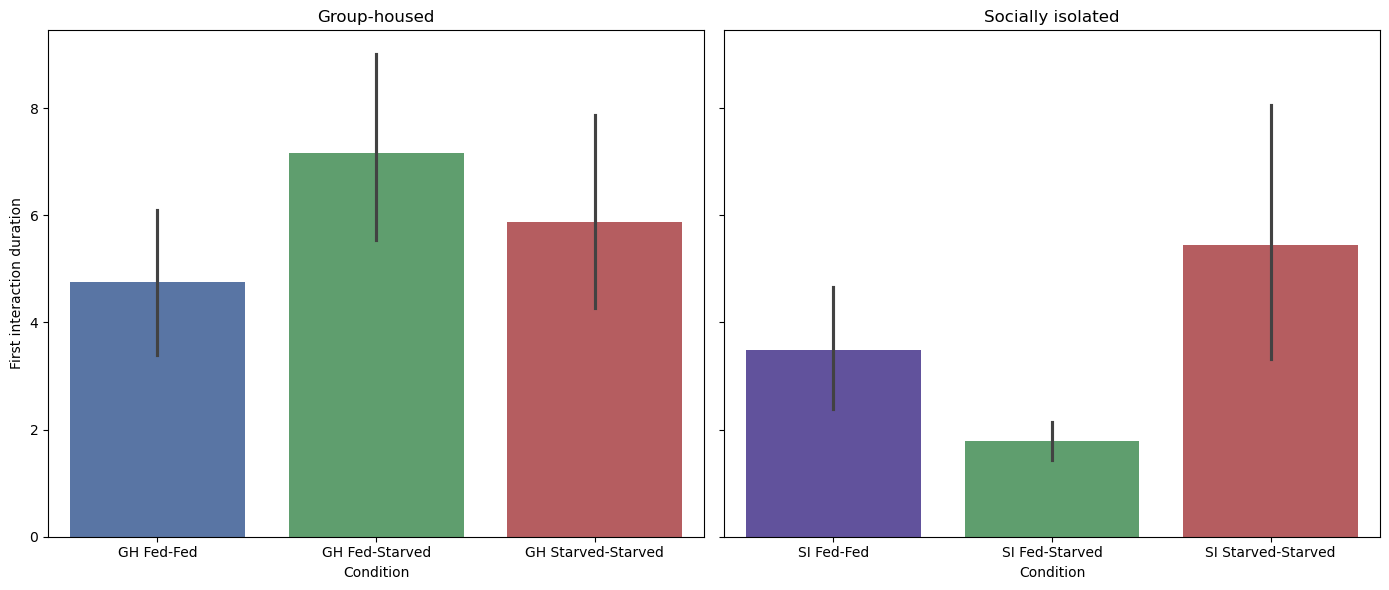

In [28]:
# First interaction in each file
gh_first = gh[gh['interaction_number'] == 1].copy()
si_first = si[si['interaction_number'] == 1].copy()
plot_df = pd.concat([gh_first, si_first], ignore_index=True)


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_first,
    x='Condition',
    y='duration',
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('First interaction duration')

# ---------------- SI ----------------
sns.barplot(
    data=si_first,
    x='Condition',
    y='duration',

    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


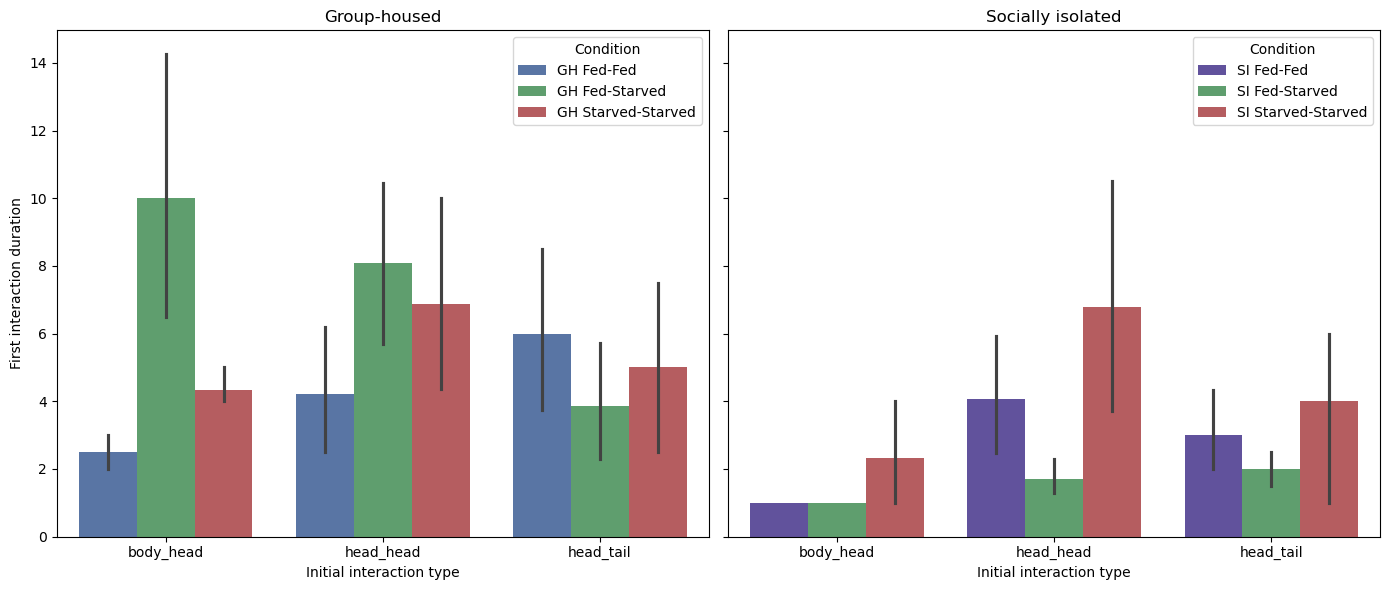

In [29]:
# First interaction in each file
gh_first = gh[gh['interaction_number'] == 1].copy()
si_first = si[si['interaction_number'] == 1].copy()
plot_df = pd.concat([gh_first, si_first], ignore_index=True)

order = sorted(plot_df['initial_type'].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_first,
    x='initial_type',
    y='duration',
    hue='Condition',
    order=order,
    hue_order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('First interaction duration')

# ---------------- SI ----------------
sns.barplot(
    data=si_first,
    x='initial_type',
    y='duration',
    hue='Condition',
    order=order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [30]:
target_type = 'body_head'

for group_name, data in [('GH', gh_first), ('SI', si_first)]:
    print(f"\n===== {group_name} =====")

    sub = data[data['initial_type'] == target_type].copy()

    if sub.empty:
        print(f"No first interactions with initial_type = {target_type}")
    else:
        for _, row in sub.sort_values(['Condition', 'file', 'start_frame']).iterrows():
            print(
                f"{row['Condition']} | "
                f"file: {row['file']} | "
                f"start_frame: {row['start_frame']} | "
                f"duration: {row['duration']}"
            )


===== GH =====
GH Fed-Fed | file: 2026-05-12_14-51-49_td19.tracks.feather | start_frame: 757 | duration: 3
GH Fed-Fed | file: 2026-06-23_15-57-37_td20.tracks.feather | start_frame: 1835 | duration: 2
GH Fed-Starved | file: 2026-04-28_12-25-04_td15.tracks.feather | start_frame: 94 | duration: 12
GH Fed-Starved | file: 2026-05-12_14-58-32_td17.tracks.feather | start_frame: 2655 | duration: 8
GH Fed-Starved | file: 2026-05-18_12-09-27_td15.tracks.feather | start_frame: 3247 | duration: 15
GH Fed-Starved | file: 2026-05-18_15-26-58_td8.tracks.feather | start_frame: 1074 | duration: 5
GH Starved-Starved | file: 2026-06-05_12-15-59_td14.tracks.feather | start_frame: 93 | duration: 5
GH Starved-Starved | file: 2026-06-23_15-59-08_td13.tracks.feather | start_frame: 355 | duration: 4
GH Starved-Starved | file: 2026-06-23_15-59-36_td14.tracks.feather | start_frame: 541 | duration: 4

===== SI =====
SI Fed-Fed | file: 2026-05-12_14-41-39_td8.tracks.feather | start_frame: 2576 | duration: 1
SI Fe

In [31]:
# Number of first interactions per condition and initial interaction type
first_counts = (
    plot_df.groupby(['Condition', 'initial_type'], as_index=False)
      .size()
      .rename(columns={'size': 'n'})
)

first_counts = (
    first_counts.pivot(
        index='initial_type',
        columns='Condition',
        values='n'
    )
    .reindex(index=order, columns=gh_order + si_order)
    .fillna(0)
    .astype(int)
)

display(first_counts)


Condition,GH Fed-Fed,GH Fed-Starved,GH Starved-Starved,SI Fed-Fed,SI Fed-Starved,SI Starved-Starved
initial_type,,,,,,
body_head,2,4,3,2,1,3
head_head,10,13,8,13,7,10
head_tail,8,7,4,6,6,3


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/290362995.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/290362995.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


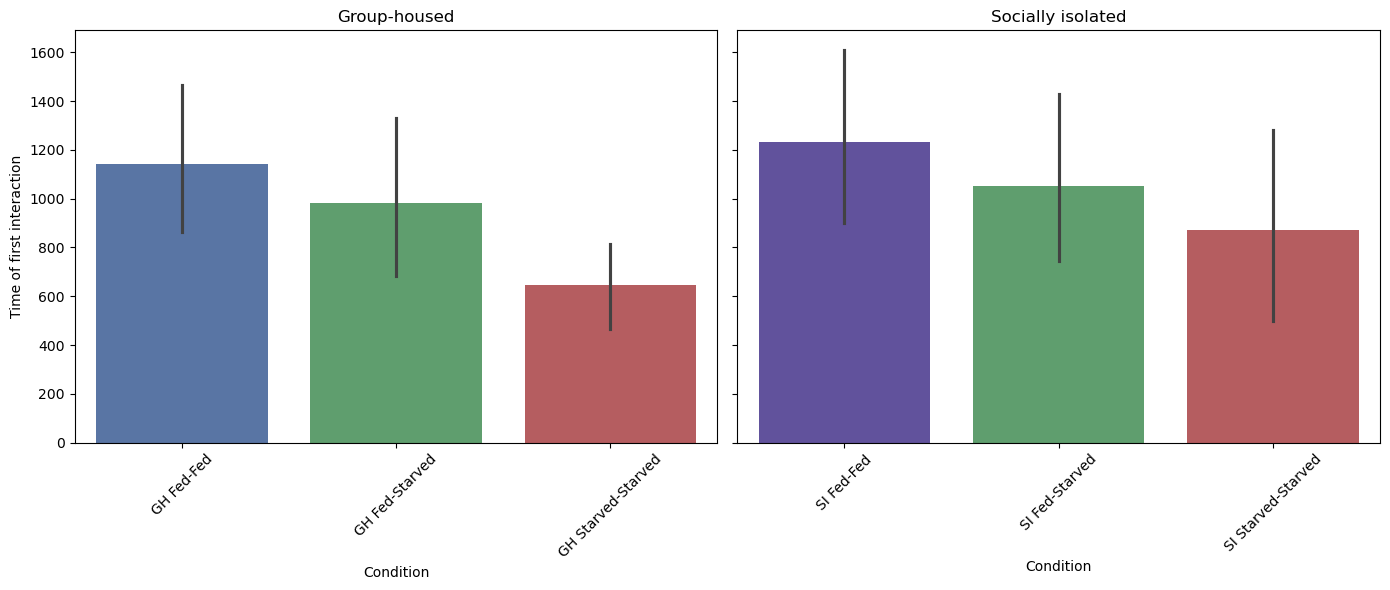

In [32]:
# Time of first interaction
gh_first = gh[gh['interaction_number'] == 1].copy()
si_first = si[si['interaction_number'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_first,
    x='Condition',
    y='start_frame',
    order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Time of first interaction')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.barplot(
    data=si_first,
    x='Condition',
    y='start_frame',
    order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [33]:
gh_first_stats = simple_stats(gh_first, gh_order, 'GH', 'start_frame')
si_first_stats = simple_stats(si_first, si_order, 'SI', 'start_frame')


===== GH =====
Kruskal-Wallis: H = 4.647, p = 0.0979


,group,comparison,median_1,median_2,p_value,p_fdr
0,GH,GH Fed-Fed vs GH Fed-Starved,1073.5,712.5,0.252974,0.379461
1,GH,GH Fed-Fed vs GH Starved-Starved,1073.5,774.0,0.017941,0.053823
2,GH,GH Fed-Starved vs GH Starved-Starved,712.5,774.0,0.479409,0.479409



===== SI =====
Kruskal-Wallis: H = 2.495, p = 0.2872


,group,comparison,median_1,median_2,p_value,p_fdr
0,SI,SI Fed-Fed vs SI Fed-Starved,994.0,842.5,0.555690,0.555690
1,SI,SI Fed-Fed vs SI Starved-Starved,994.0,720.5,0.121580,0.364739
2,SI,SI Fed-Starved vs SI Starved-Starved,842.5,720.5,0.394105,0.555690


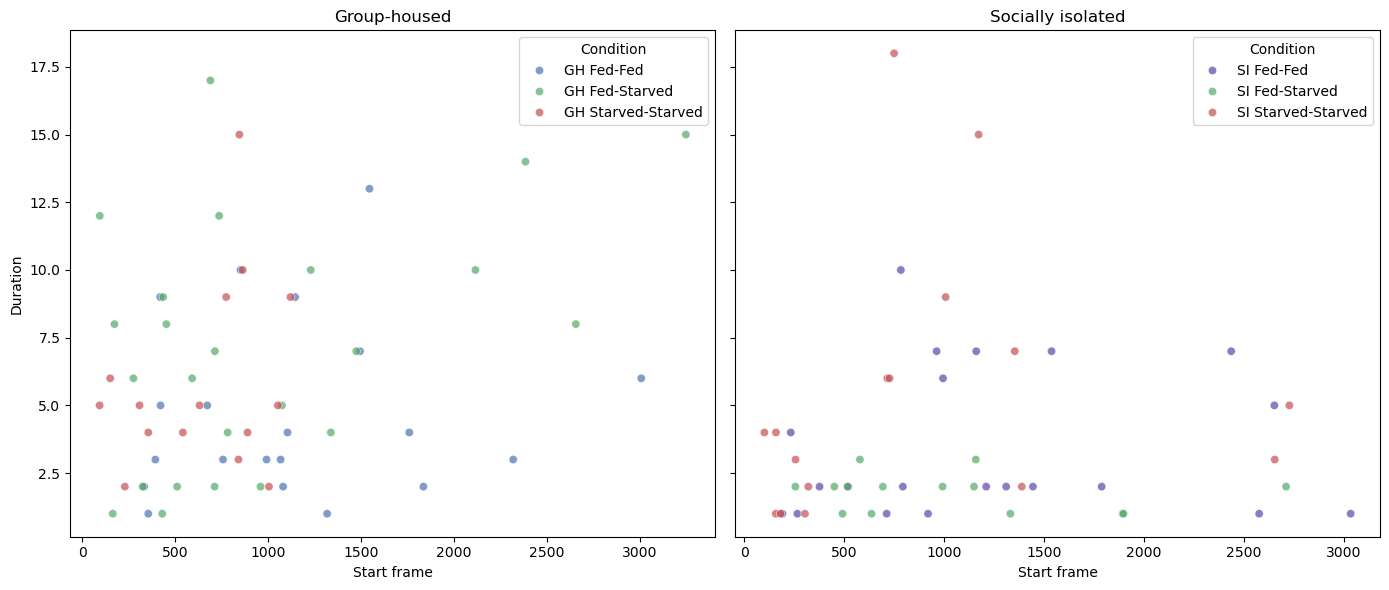

In [34]:
# First interaction start frame and duration
gh_first = gh[gh['interaction_number'] == 1].copy()
si_first = si[si['interaction_number'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.scatterplot(
    data=gh_first,
    x='start_frame',
    y='duration',
    hue='Condition',
    hue_order=gh_order,
    palette=palette_gh,
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Start frame')
axes[0].set_ylabel('Duration')

# ---------------- SI ----------------
sns.scatterplot(
    data=si_first,
    x='start_frame',
    y='duration',
    hue='Condition',
    hue_order=si_order,
    palette=palette_si,
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Start frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


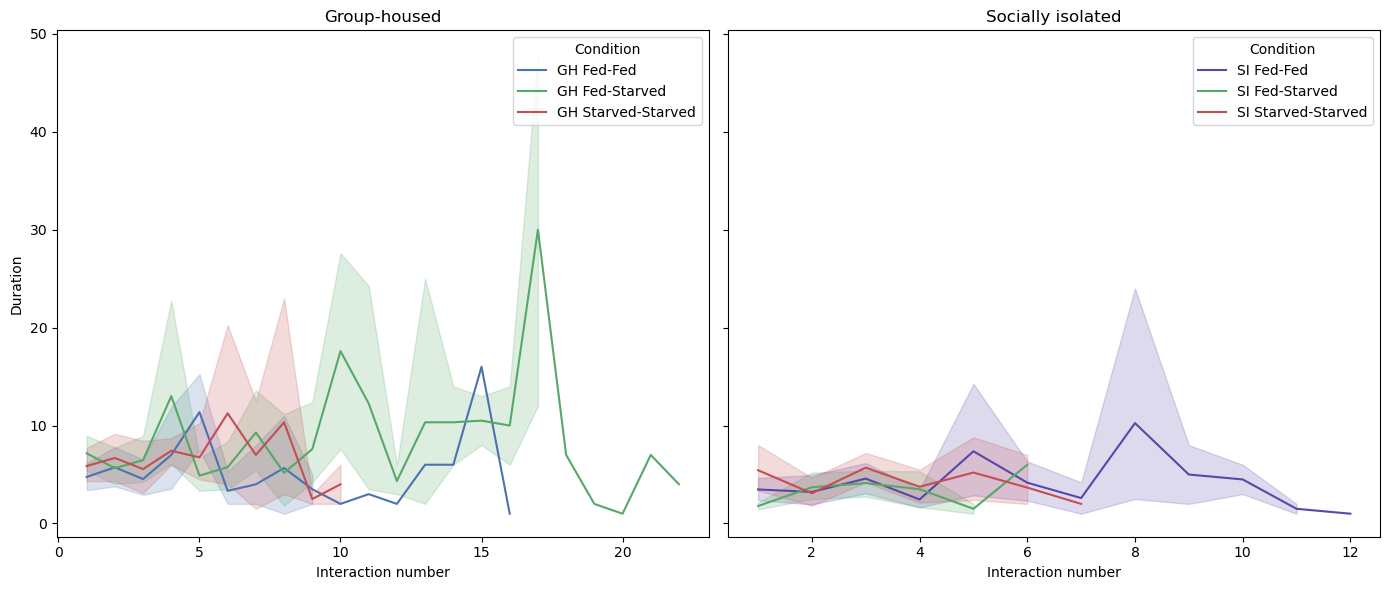

In [35]:
# Mean duration by interaction number
duration_by_interaction = (
    df.groupby(['Condition', 'file', 'interaction_number'], as_index=False)['duration']
      .mean()
)

gh_duration = duration_by_interaction[duration_by_interaction['Condition'].str.contains('GH')].copy()
si_duration = duration_by_interaction[duration_by_interaction['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=gh_duration,
    x='interaction_number',
    y='duration',
    hue='Condition',
    hue_order=gh_order,
    palette=palette_gh,
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Interaction number')
axes[0].set_ylabel('Duration')

# ---------------- SI ----------------
sns.lineplot(
    data=si_duration,
    x='interaction_number',
    y='duration',
    hue='Condition',
    hue_order=si_order,
    palette=palette_si,
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Interaction number')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/1300085514.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14804/1300085514.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


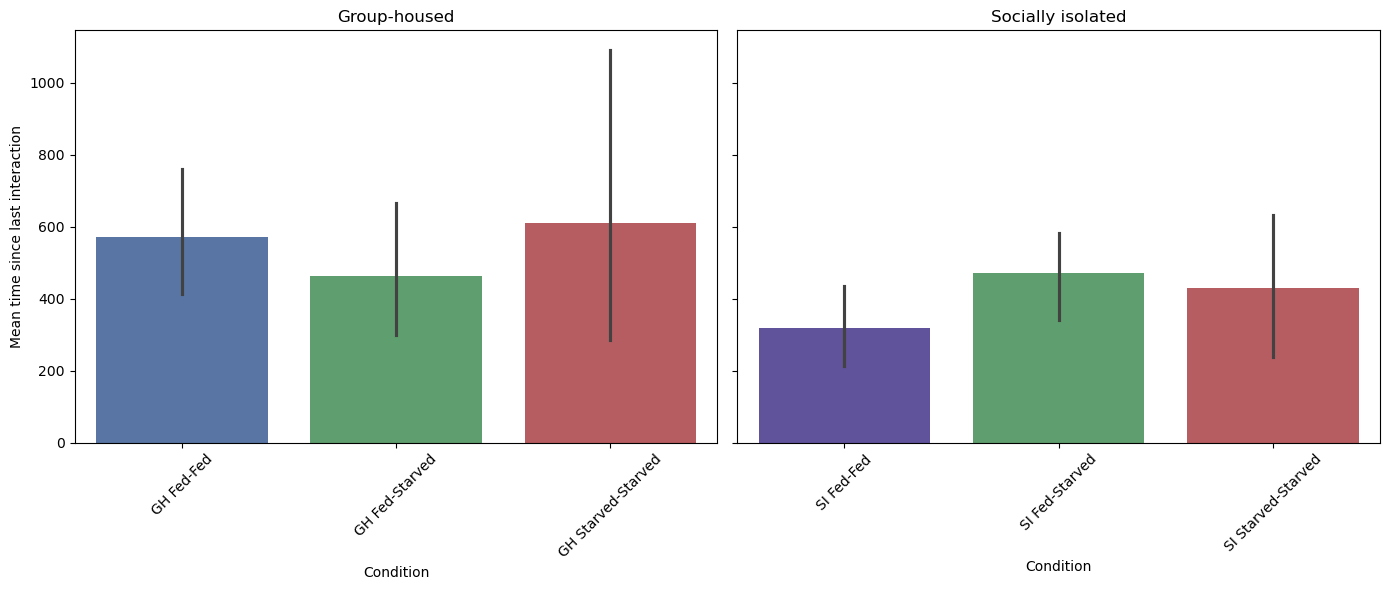

In [36]:
# Mean time since previous interaction per file
df = df.sort_values(['Condition', 'file', 'start_frame']).copy()

df['time_since_last_interaction'] = (
    df.groupby(['Condition', 'file'])['start_frame']
      .diff()
)

time_between_file = (
    df.groupby(['Condition', 'file'], as_index=False)['time_since_last_interaction']
      .mean()
)

gh_time = time_between_file[time_between_file['Condition'].str.contains('GH')].copy()
si_time = time_between_file[time_between_file['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_time,
    x='Condition',
    y='time_since_last_interaction',
    order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Mean time since last interaction')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.barplot(
    data=si_time,
    x='Condition',
    y='time_since_last_interaction',
    order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
